I made this code to create a wordcloud for LinkedIN and Twitter profile backgrounds.\
* The dimensions are suitable for each social media platform.\
* Customize the words used in the wordcloud using the .txt file.

In [1]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [3]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import random
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

In [4]:
# Download NLTK data files (if not already downloaded)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /home/mark.zais/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/mark.zais/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/mark.zais/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/mark.zais/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/mark.zais/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/mark.zais/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [5]:
# Read file
fileName = "linkedin2.txt"
with open(fileName, 'r') as file:
    text = file.read().replace('\n', ' ')

In [6]:
# Text processing
words = word_tokenize(text)
tags = nltk.pos_tag(words)
lem = WordNetLemmatizer()

lemWords = []
for word, tag in tags:
    if tag.startswith('VB'):
        lemWord = lem.lemmatize(word, 'v')
    else:
        lemWord = lem.lemmatize(word)
    lemWords.append(lemWord)

finalText = ' '.join(lemWords)

In [7]:
# Create LinkedIn word cloud
linkedin_wordcloud = WordCloud(
    width=1584, height=396,
    background_color='black',
    min_font_size=20,
    max_font_size=50,
    repeat=True,
    relative_scaling=0,
    normalize_plurals=False,
    min_word_length=1,
    random_state=34
).generate(finalText)

In [8]:
# Create Twitter word cloud
twitter_wordcloud = WordCloud(
    width=1263, height=421,
    background_color='black',
    min_font_size=20,
    max_font_size=50,
    repeat=True,
    relative_scaling=0,
    normalize_plurals=False,
    min_word_length=1,
    random_state=44
).generate(finalText)

In [9]:
# Custom color function for grey scale
def grey_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    return f"hsl(0, 0%, {random.randint(60, 100)}%)"

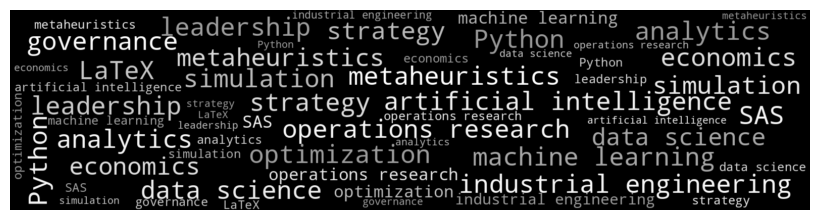

In [10]:
# Plot LinkedIn word cloud
plt.figure(figsize=(8, 2), facecolor=None)
plt.imshow(linkedin_wordcloud.recolor(color_func=grey_color_func, random_state=2), interpolation="bilinear")
plt.axis("off")
plt.tight_layout(pad=0)
plt.savefig("linkedin_wordcloud.png")
plt.show()

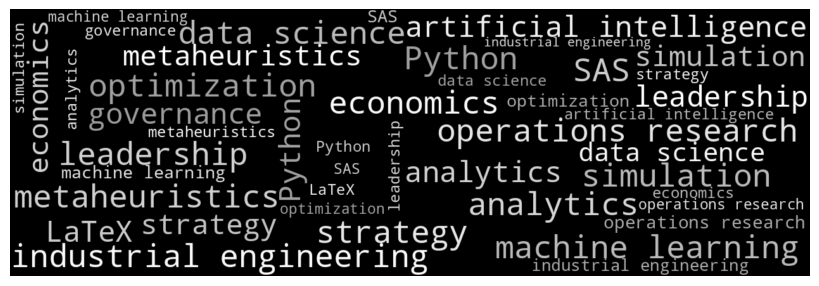

In [11]:
# Plot Twitter word cloud
plt.figure(figsize=(8, 2.67), facecolor=None)
plt.imshow(twitter_wordcloud.recolor(color_func=grey_color_func, random_state=3), interpolation="bilinear")
plt.axis("off")
plt.tight_layout(pad=0)
plt.savefig("twitter_wordcloud.png")
plt.show()

In [12]:
# Create condensed (width) LinkedIn word cloud so that I can attach a picture to the right
linkedin_wordcloud2 = WordCloud(
    width= 960, height=396,
    background_color='black',
    min_font_size=20,
    max_font_size=50,
    repeat=True,
    relative_scaling=0,
    normalize_plurals=False,
    min_word_length=1,
    random_state=34
).generate(finalText)

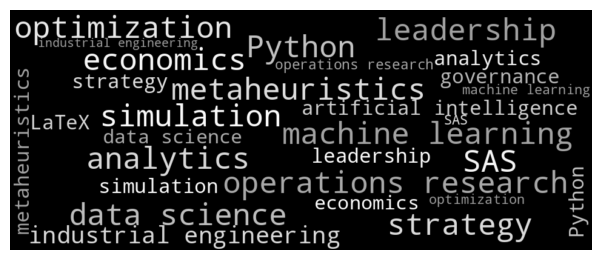

In [13]:
# Plot condensed LinkedIn word cloud
plt.figure(figsize=(6.2, 2.4), facecolor=None)
plt.imshow(linkedin_wordcloud2.recolor(color_func=grey_color_func, random_state=2), interpolation="bilinear")
plt.axis("off")
plt.tight_layout(pad=0)
plt.savefig("linkedin_wordcloud2.png")
plt.show()